# Optogenetics Data — TaskSwitch6, P131, 190815a

This notebook demonstrates how optogenetic stimulation data is stored in the NWB file and how to access it.

The session  used the **Cerebro wireless optogenetics system** to bilaterally inactivate the Frontal Orienting Field (FOF) on most trials.

**Reference:** Pagan et al., *Nature* 639, 421–429 (2025). doi:10.1038/s41586-024-08433-6

## Stream the NWB file from DANDI

This session is uploaded to **[DANDI:001550](https://dandiarchive.org/dandiset/001550)**.
We use `dandi` + `remfile` to stream it directly — no local download needed.

To install the required packages:
```
pip install dandi remfile
```

In [25]:
import h5py
import numpy as np
import pandas as pd
import remfile
from dandi.dandiapi import DandiAPIClient
from matplotlib import pyplot as plt
from pynwb import NWBHDF5IO

DANDISET_ID = "001550"
ASSET_PATH  = "sub-P131/sub-P131_ses-TaskSwitch6-190815a.nwb"

# Resolve the S3 streaming URL from the DANDI archive
with DandiAPIClient() as client:
    asset = client.get_dandiset(DANDISET_ID, "draft").get_asset_by_path(ASSET_PATH)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

print(f"Streaming: {s3_url[:80]}...")

# remfile provides the HTTP byte-range backend; h5py wraps it as an HDF5 file object
remote_file = remfile.File(s3_url)
h5_file = h5py.File(remote_file, "r")
io = NWBHDF5IO(file=h5_file, mode="r", load_namespaces=True)
nwb = io.read()
print(f"Loaded session: {nwb.session_id}")

Streaming: https://dandiarchive.s3.amazonaws.com/blobs/f2e/f37/f2ef3776-711a-42ee-af13-6e15...
Loaded session: TaskSwitch6-190815a


## Session and subject metadata

In [26]:
print("Session ID:     ", nwb.session_id)
print("Session start:  ", nwb.session_start_time)
sub = nwb.subject
print("Subject ID:     ", sub.subject_id)
print("Species:        ", sub.species)
print("Strain:         ", sub.strain)
print("Sex:            ", sub.sex)
print("Date of birth:  ", sub.date_of_birth.date())

Session ID:      TaskSwitch6-190815a
Session start:   2019-08-15 11:41:00+01:00
Subject ID:      P131
Species:         Rattus norvegicus
Strain:          Long Evans
Sex:             M
Date of birth:   2017-06-27


## Optical fiber implants

Two `OpticalFiber` objects (from [ndx-optogenetics](https://github.com/rly/ndx-optogenetics)) describe the implant locations — one per hemisphere.
The virus **AAV2/5-mDlx-ChR2-mCherry** was used to express ChR2; stimulation wavelength is 473 nm.
The Cerebro wireless system (Karpova Lab) delivered the light bilaterally.

In [27]:
for name, device in nwb.devices.items():
    fiber_type = type(device).__name__
    if fiber_type != "OpticalFiber":
        continue
    fi = device.fiber_insertion
    model = device.model
    print(f"--- {name} ---")
    print(f"  Description:  {device.description}")
    print(f"  AP:           {fi.insertion_position_ap_in_mm:+.1f} mm")
    print(f"  ML:           {fi.insertion_position_ml_in_mm:+.1f} mm")
    if model:
        print(f"  Model:        {model.name}  (NA={model.numerical_aperture}, core={model.core_diameter_in_um} µm)")

--- optical_fiber_left ---
  Description:  Optical fiber implanted in the left hemisphere FOF (+2 mm AP, -1.3 mm ML from bregma).
  AP:           +2.0 mm
  ML:           -1.3 mm
  Model:        fof_fiber_model  (NA=0.37, core=400.0 µm)
--- optical_fiber_right ---
  Description:  Optical fiber implanted in the right hemisphere FOF (+2 mm AP, +1.3 mm ML from bregma).
  AP:           +2.0 mm
  ML:           +1.3 mm
  Model:        fof_fiber_model  (NA=0.37, core=400.0 µm)


## Structured optogenetics metadata (ndx-optogenetics)

Rich optogenetics metadata is stored using the [ndx-optogenetics](https://github.com/rly/ndx-optogenetics) NWB extension inside an `OptogeneticExperimentMetadata` object in `nwbfile.lab_meta_data`.

This provides structured, queryable fields for:
- **Excitation source** — device model, wavelength, power
- **Optical fiber** — model specs (NA, core diameter), per-hemisphere implant coordinates
- **Virus** — construct name, manufacturer, titer
- **Virus injections** — stereotactic coordinates per hemisphere

In [29]:
opto_meta = nwb.lab_meta_data["optogenetic_experiment_metadata"]
print("Stimulation software:", opto_meta.stimulation_software)

cerebro = nwb.devices["Cerebro"]
print(f"\nExcitation source: {cerebro.name}  (manufacturer: {cerebro.manufacturer})")
print(f"  Power:      {cerebro.power_in_W * 1000:.0f} mW")

# Wavelength is recorded per epoch in the OptogeneticEpochsTable
epochs_tbl = nwb.intervals["opto_epochs"]
print(f"  Wavelength: {epochs_tbl['wavelength_in_nm'][0]:.0f} nm  (from epochs table)")

# OptogeneticSitesTable — one row per hemisphere implant
sites_table = opto_meta.optogenetic_sites_table
print(f"\nOptogenetic sites ({len(sites_table.id)} implant locations):")
for i in range(len(sites_table.id)):
    fiber = sites_table["optical_fiber"][i]
    fi    = fiber.fiber_insertion
    print(
        f"  Site {i}: {fiber.description}\n"
        f"           AP={fi.insertion_position_ap_in_mm:+.1f} mm  "
        f"ML={fi.insertion_position_ml_in_mm:+.1f} mm"
    )

virus = next(iter(opto_meta.optogenetic_viruses.viral_vectors.values()))
print(f"\nVirus construct: {virus.construct_name}")
print(f"  Manufacturer:  {virus.manufacturer}")

print("\nVirus injections:")
for inj in opto_meta.optogenetic_virus_injections.viral_vector_injections.values():
    print(
        f"  {inj.hemisphere:6s}  "
        f"AP={inj.ap_in_mm:+.1f} mm  "
        f"ML={inj.ml_in_mm:+.1f} mm  "
        f"→ {inj.location}"
    )

Stimulation software: BControl / Cerebro

Excitation source: Cerebro  (manufacturer: Karpova Lab)
  Power:      25 mW
  Wavelength: 473 nm  (from epochs table)

Optogenetic sites (2 implant locations):
  Site 0: Optical fiber implanted in the left hemisphere FOF (+2 mm AP, -1.3 mm ML from bregma).
           AP=+2.0 mm  ML=-1.3 mm
  Site 1: Optical fiber implanted in the right hemisphere FOF (+2 mm AP, +1.3 mm ML from bregma).
           AP=+2.0 mm  ML=+1.3 mm

Virus construct: AAV2/5-mDlx-ChR2-mCherry
  Manufacturer:  unknown

Virus injections:
  left    AP=+2.0 mm  ML=-1.3 mm  → Frontal Orienting Field (FOF)
  right   AP=+2.0 mm  ML=+1.3 mm  → Frontal Orienting Field (FOF)


## Per-trial opto metadata from the trials table

Two opto-related columns are stored directly in the trials table:

| Column | Content |
|---|---|
| `OptoSection_opto_connected` | 1 = Cerebro was connected on this trial (stimulated or not); 0 = system disconnected |
| `OptoSection_opto_type` | Stimulation window label: `'Full Trial'` (0–1.3 s), `'First Half'` (0–0.65 s), or `'Second Half'` (0.65–1.3 s) relative to cpoke onset |

Per-hemisphere stimulation history is available in `HistorySection_opto_left_history` and `HistorySection_opto_right_history`.

## OptogeneticEpochsTable — per-trial stimulation parameters

`nwb.intervals["opto_epochs"]` contains one row per stimulation interval with structured protocol fields: `stimulation_on`, `pulse_length_in_ms`, `period_in_ms`, `number_pulses_per_pulse_train`, `power_in_mW`, `wavelength_in_nm`, etc.

The `optogenetic_sites` column references the `OptogeneticSitesTable` (site 0 = left FOF, site 1 = right FOF) and reflects which hemisphere was actually stimulated on each trial — left only `[0]`, right only `[1]`, or both `[0, 1]`.

In [30]:
epochs = nwb.intervals["opto_epochs"]
n_epochs = len(epochs.id)
print(f"Total stimulation epochs: {n_epochs}")

epochs_df = pd.DataFrame({
    "start_time":          epochs["start_time"][:],
    "stop_time":           epochs["stop_time"][:],
    "stimulation_on":      epochs["stimulation_on"][:],
    "pulse_length_in_ms":  epochs["pulse_length_in_ms"][:],
    "power_in_mW":         epochs["power_in_mW"][:],
})

print("\nWindow-type distribution (by pulse_length_in_ms):")
print(epochs_df["pulse_length_in_ms"].value_counts().rename(
    {1300.0: "Full Trial (1300 ms)", 650.0: "Half Trial (650 ms)"}
).to_string())
print()
epochs_df.head(10)

Total stimulation epochs: 205

Window-type distribution (by pulse_length_in_ms):
pulse_length_in_ms
Half Trial (650 ms)     142
Full Trial (1300 ms)     63



,start_time,stop_time,stimulation_on,pulse_length_in_ms,power_in_mW
0,1457.688753,1458.338753,True,650.0,25.0
1,1488.349256,1488.999256,True,650.0,25.0
2,1516.250754,1517.550754,True,1300.0,25.0
3,1541.370253,1542.020253,True,650.0,25.0
4,1580.621753,1581.271753,True,650.0,25.0
5,1606.274253,1606.924253,True,650.0,25.0
6,1632.856753,1633.506753,True,650.0,25.0
7,1657.821255,1658.471255,True,650.0,25.0
8,1684.191754,1684.841754,True,650.0,25.0
9,1717.957253,1719.257253,True,1300.0,25.0


In [31]:
trials_df = nwb.trials.to_dataframe()
opto_cols = [c for c in trials_df.columns if "opto" in c.lower()]
print("Opto-related trial columns:", opto_cols)
trials_df[["OptoSection_opto_connected", "OptoSection_opto_type"]].head(10)

Opto-related trial columns: ['HistorySection_opto_left_history', 'HistorySection_opto_right_history', 'OptoSection_opto_connected', 'OptoSection_opto_type']


,OptoSection_opto_connected,OptoSection_opto_type
id,,
0,0,Full Trial
1,1,Full Trial
2,1,First Half
3,1,First Half
4,1,First Half
5,1,Second Half
6,1,Second Half
7,1,Second Half
8,1,Full Trial


## Recovering per-trial hemisphere stimulation

Per-hemisphere stimulation history is stored in the BControl-derived trial columns
`HistorySection_opto_left_history` and `HistorySection_opto_right_history`.
These record which hemisphere received stimulation on each trial.

In [32]:
stim_left  = np.array(trials_df["HistorySection_opto_left_history"])
stim_right = np.array(trials_df["HistorySection_opto_right_history"])

trials_df["stim_left"]  = stim_left > 0
trials_df["stim_right"] = stim_right > 0

print("Hemisphere stimulation distribution (connected trials only):")
connected = trials_df[trials_df["OptoSection_opto_connected"] == 1]
print(connected[["stim_left", "stim_right"]].value_counts().to_string())
print()
trials_df[["OptoSection_opto_connected", "OptoSection_opto_type", "stim_left", "stim_right"]].head(10)

Hemisphere stimulation distribution (connected trials only):
stim_left  stim_right
False      False         411
True       False          77
False      True           68
True       True           60



,OptoSection_opto_connected,OptoSection_opto_type,stim_left,stim_right
id,,,,
0,0,Full Trial,False,False
1,1,Full Trial,False,False
2,1,First Half,True,True
3,1,First Half,False,False
4,1,First Half,False,False
5,1,Second Half,False,True
6,1,Second Half,False,False
7,1,Second Half,False,False
8,1,Full Trial,True,False


## Link stimulation epochs to trial timing

Join the `opto_epochs` table to the trials table by matching each epoch's
`start_time` to the expected stimulation onset (`cpoke_start_time` + window offset).
This produces a per-trial summary of stimulation timing and hemisphere.

In [33]:
OPTO_WINDOWS = {
    "Full Trial":  (0.0, 1.3),
    "First Half":  (0.0, 0.65),
    "Second Half": (0.65, 1.3),
}

records = []
for i in range(len(nwb.trials)):
    connected = trials_df["OptoSection_opto_connected"].iloc[i]
    if not connected:
        continue
    cpoke = nwb.trials["cpoke_start_time"][i]
    otype = trials_df["OptoSection_opto_type"].iloc[i]
    win_start, win_stop = OPTO_WINDOWS.get(otype, (0.0, 1.3))
    records.append({
        "trial":       i,
        "opto_type":   otype,
        "cpoke_start": cpoke,
        "stim_on":     float("nan") if np.isnan(cpoke) else cpoke + win_start,
        "stim_off":    float("nan") if np.isnan(cpoke) else cpoke + win_stop,
        "stim_left":   trials_df["stim_left"].iloc[i],
        "stim_right":  trials_df["stim_right"].iloc[i],
    })

opto_trials = pd.DataFrame(records)
print(f"Trials with Cerebro connected: {len(opto_trials)}")
print("\nopto_type distribution:")
print(opto_trials["opto_type"].value_counts().to_string())
opto_trials.head(10)

Trials with Cerebro connected: 616

opto_type distribution:
opto_type
First Half     213
Second Half    213
Full Trial     190


,trial,opto_type,cpoke_start,stim_on,stim_off,stim_left,stim_right
0,1,Full Trial,1449.866753,1449.866753,1451.166753,False,False
1,2,First Half,1457.688753,1457.688753,1458.338753,True,True
2,3,First Half,1468.262754,1468.262754,1468.912754,False,False
3,4,First Half,1475.819754,1475.819754,1476.469754,False,False
4,5,Second Half,1487.699256,1488.349256,1488.999256,False,True
5,6,Second Half,1498.700754,1499.350754,1500.000754,False,False
6,7,Second Half,1506.551258,1507.201258,1507.851258,False,False
7,8,Full Trial,1516.250754,1516.250754,1517.550754,True,False
8,9,Full Trial,1523.471254,1523.471254,1524.771254,False,False
9,10,Full Trial,1531.310753,1531.310753,1532.610753,False,False


## Visualise stimulation epochs over time

Each epoch is shown as a coloured horizontal bar at the stimulated hemisphere row:
- **Blue** — left FOF only
- **Red** — right FOF only
- **Purple** — both hemispheres


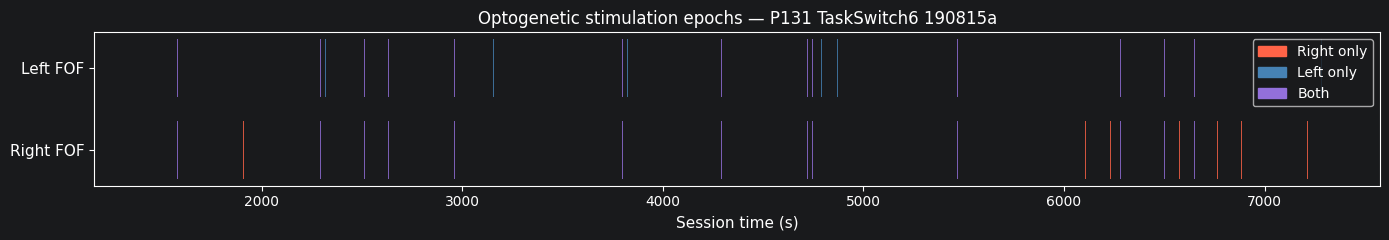

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLOR = {(False, True): "tomato", (True, False): "steelblue", (True, True): "mediumpurple"}
LABEL = {(False, True): "Right only", (True, False): "Left only", (True, True): "Both"}
YPOS  = {"left": 1.0, "right": 0.0}

fig, ax = plt.subplots(figsize=(14, 2.5))
for _, row in opto_trials.dropna(subset=["stim_on"]).iterrows():
    key = (bool(row["stim_left"]), bool(row["stim_right"]))
    if key not in COLOR:
        continue
    color = COLOR[key]
    duration = row["stim_off"] - row["stim_on"]
    if row["stim_left"]:
        ax.broken_barh([(row["stim_on"], duration)], (YPOS["left"] - 0.35, 0.7),
                       facecolors=color, alpha=0.8)
    if row["stim_right"]:
        ax.broken_barh([(row["stim_on"], duration)], (YPOS["right"] - 0.35, 0.7),
                       facecolors=color, alpha=0.8)

ax.set_yticks([0, 1])
ax.set_yticklabels(["Right FOF", "Left FOF"], fontsize=11)
ax.set_xlabel("Session time (s)", fontsize=11)
ax.set_title("Optogenetic stimulation epochs — P131 TaskSwitch6 190815a", fontsize=12)
legend_patches = [mpatches.Patch(color=c, label=LABEL[k]) for k, c in COLOR.items()]
ax.legend(handles=legend_patches, loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()


In [35]:
nwb.trials[:]

,start_time,stop_time,states,events,actions,cpoke_start_time,left_hi,right_hi,left_lo,right_lo,...,HistorySection_quadrant_history,HistorySection_task_history,HistorySection_incoh_history,HistorySection_gammadir_history,HistorySection_gammafreq_history,HistorySection_result_history,HistorySection_opto_left_history,HistorySection_opto_right_history,OptoSection_opto_connected,OptoSection_opto_type
id,,,,,,,,,,,,,,,,,,,,,
0,1426.550753,1445.614254,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]","[0, 1, 2, 3, 4, 5]","[0, 1, 2]",1440.938754,[],"[0.01842, 0.07042, 0.420615]",[],"[0.00171, 0.037, 0.04252, 0.04527, 0.08372, 0....",...,1,d,1,4.0,-2.5,3,0,0,0,Full Trial
1,1445.614753,1455.668754,"[14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 2...","[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]","[3, 4, 5, 6]",1449.866753,[],"[0.02414, 0.21247, 0.287775, 0.293555, 0.54593...","[0.504595, 0.551575, 0.87734, 1.00831, 1.15587]","[0.035055, 0.057625, 0.062735, 0.132995, 0.148...",...,1,d,1,2.5,-1.0,1,0,0,1,Full Trial
2,1455.669255,1462.974753,"[34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 4...","[19, 20, 21, 22, 23, 24, 25, 26, 27]","[7, 8, 9]",1457.688753,"[0.08778, 0.10681, 0.300405, 0.397145, 0.43750...","[0.005325, 0.04738, 0.05887, 0.059205, 0.06422...",[],[],...,4,d,0,1.0,4.0,3,1020,1020,1,First Half
3,1462.975259,1473.800254,"[52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 6...","[28, 29, 30]","[10, 11, 12]",1468.262754,"[0.278885, 0.296635]",[],"[0.017075, 0.03374, 0.04821, 0.049495, 0.10852...","[0.334955, 1.077265]",...,2,d,0,-4.0,-4.0,3,0,0,1,First Half
4,1473.800753,1481.767753,"[70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 8...","[31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 4...","[13, 14, 15, 16]",1475.819754,"[0.15262, 0.21278, 0.238475, 0.261195, 0.29171...",[],"[0.06016, 0.102655, 0.11773, 0.176895, 0.18359...",[],...,2,d,0,-4.0,-1.0,1,0,0,1,First Half
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,7265.970253,7272.879254,"[11497, 11498, 11499, 11500, 11501, 11502, 115...","[5762, 5763, 5764, 5765, 5766]","[2064, 2065, 2066]",7268.030253,"[0.24806, 0.30622, 0.452435, 0.627865, 0.72215...",[0.07539],"[0.0137, 0.023615, 0.067225, 0.06849, 0.083605...","[0.622645, 1.07987]",...,2,f,0,-2.5,-1.0,3,0,0,1,Second Half
613,7272.879754,7280.922254,"[11513, 11514, 11515, 11516, 11517, 11518, 115...","[5767, 5768, 5769, 5770, 5771, 5772, 5773, 5774]","[2067, 2068, 2069]",7274.906254,"[0.00166, 0.03164, 0.21101, 0.227965, 0.32894,...","[0.191075, 1.133705]","[0.038985, 0.224065, 0.256985, 0.317585, 0.341...","[0.020985, 0.132785, 0.78641, 1.016985, 1.0221...",...,2,f,0,-1.0,-1.0,2,0,0,1,Second Half
614,7280.922753,7288.919260,"[11536, 11537, 11538, 11539, 11540, 11541, 115...","[5775, 5776, 5777, 5778, 5779, 5780, 5781, 578...","[2070, 2071, 2072, 2073]",7282.941255,"[0.114175, 0.18234, 0.194815, 0.252275, 0.2614...",[0.949715],"[0.19706, 0.6207, 0.771025]",[],...,3,f,1,-4.0,4.0,1,1020,0,1,Second Half
